# Task 6: Insights and Conclusions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx"

state_txn_users = pd.read_excel(file_path, sheet_name="State_Txn and Users")

district_txn_users = pd.read_excel(file_path, sheet_name="District_Txn and Users")

district_demo = pd.read_excel(file_path, sheet_name="District Demographics")

print("Datasets loaded successfully!")

Datasets loaded successfully!


## Task 6.1: Identify Trends or Patterns in Transaction Data

In [3]:
yearly_transactions = (
    state_txn_users
    .groupby("Year")["Transactions"]
    .sum()
    .reset_index()
)

yearly_transactions

,Year,Transactions
0,2018,1080202410
1,2019,4079827215
2,2020,7973974741
3,2021,7398955928


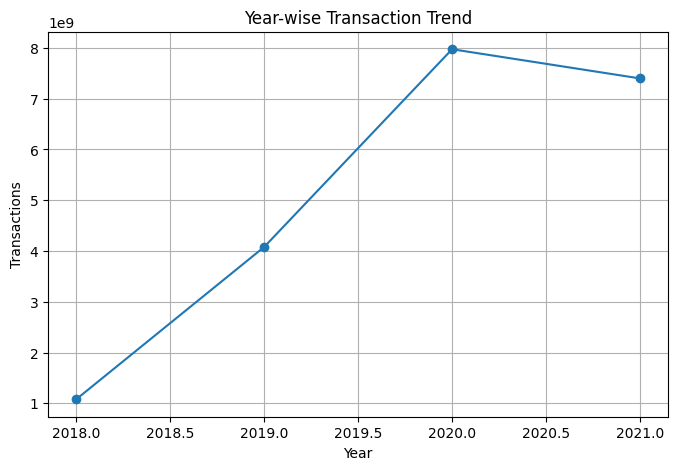

In [4]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_transactions["Year"],
    yearly_transactions["Transactions"],
    marker="o"
)

plt.title("Year-wise Transaction Trend")

plt.xlabel("Year")

plt.ylabel("Transactions")

plt.grid(True)

plt.show()

In [5]:
quarterly_transactions = (
    state_txn_users
    .groupby(["Year", "Quarter"])["Transactions"]
    .sum()
    .reset_index()
)

quarterly_transactions["Period"] = (
    quarterly_transactions["Year"].astype(str)
    + "-Q"
    + quarterly_transactions["Quarter"].astype(str)
)

quarterly_transactions

,Year,Quarter,Transactions,Period
0,2018,1,134425599,2018-Q1
1,2018,2,187365440,2018-Q2
2,2018,3,341299764,2018-Q3
3,2018,4,417111607,2018-Q4
4,2019,1,708992981,2019-Q1
5,2019,2,815380896,2019-Q2
6,2019,3,1095009675,2019-Q3
7,2019,4,1460443663,2019-Q4
8,2020,1,1623038046,2020-Q1
9,2020,2,1448608890,2020-Q2


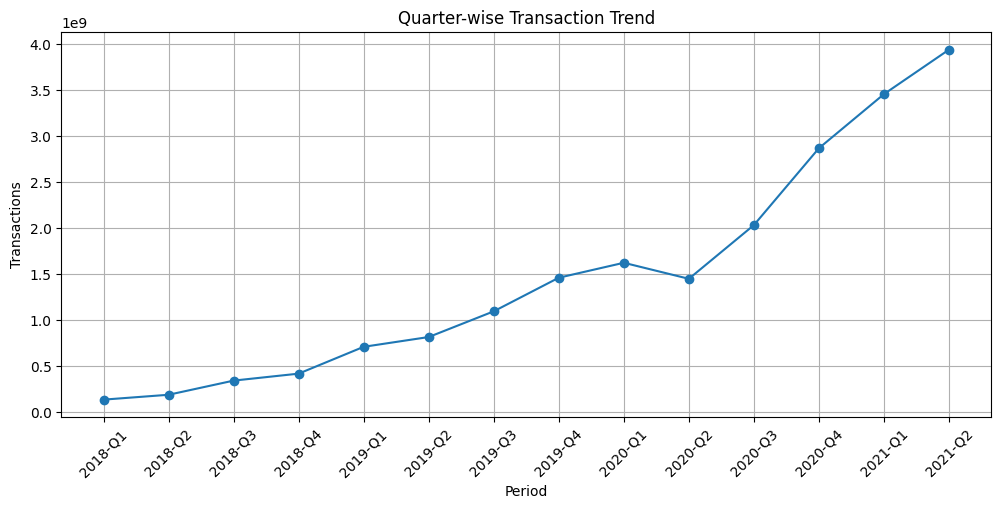

In [6]:
plt.figure(figsize=(12,5))

plt.plot(
    quarterly_transactions["Period"],
    quarterly_transactions["Transactions"],
    marker="o"
)

plt.title("Quarter-wise Transaction Trend")

plt.xlabel("Period")

plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Findings

1. Transaction volume generally increases over time.
2. Digital payment adoption is growing across states.
3. Later quarters show significantly higher transaction counts than earlier quarters.
4. The data indicates increasing user engagement with PhonePe.

## Task 6.2: Correlate Demographic Data with Transaction Data

In [7]:
district_transactions = (
    district_txn_users
    .groupby(["State", "District"])["Transactions"]
    .sum()
    .reset_index()
)

merged_data = pd.merge(
    district_transactions,
    district_demo[["State", "District", "Density"]],
    on=["State", "District"],
    how="inner"
)

merged_data.head()

,State,District,Transactions,Density
0,Andaman & Nicobar Islands,South Andaman,1014784,89
1,Andhra Pradesh,Anantapur,124411535,213
2,Andhra Pradesh,Chittoor,181284289,275
3,Andhra Pradesh,East Godavari,160754836,477
4,Andhra Pradesh,Guntur,160872479,429


In [8]:
correlation = merged_data["Density"].corr(
    merged_data["Transactions"]
)

print("Correlation:", correlation)

Correlation: 0.4188041949959691


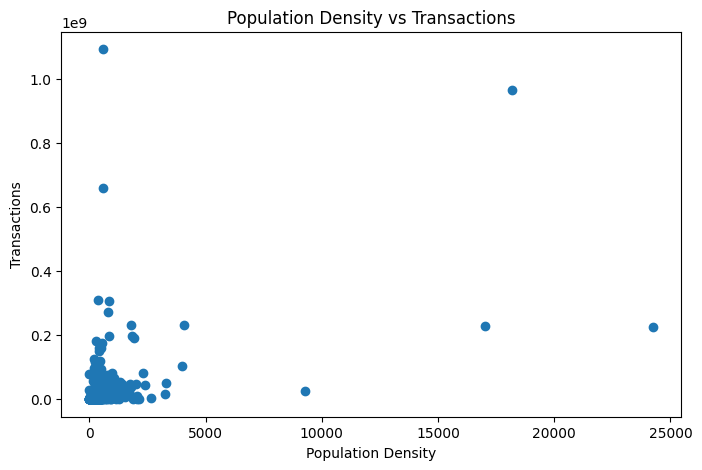

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(
    merged_data["Density"],
    merged_data["Transactions"]
)

plt.title("Population Density vs Transactions")

plt.xlabel("Population Density")

plt.ylabel("Transactions")

plt.show()

### Correlation Interpretation

- Correlation close to +1 indicates a strong positive relationship.
- Correlation close to 0 indicates a weak relationship.
- Correlation close to -1 indicates a negative relationship.

Observation:
Higher population density districts generally tend to generate higher transaction volumes, although the relationship may not be perfectly linear.

## Task 6.3: Summary of Findings and Recommendations

In [10]:
print("KEY FINDINGS")
print("-" * 50)

print("1. Transaction volume has increased consistently over time.")

print("2. States with higher registered users generate larger transaction volumes.")

print("3. Population density has a positive relationship with transaction activity.")

print("4. Digital payment adoption is growing rapidly across districts and states.")

print("5. Certain transaction types dominate the overall transaction ecosystem.")

KEY FINDINGS
--------------------------------------------------
1. Transaction volume has increased consistently over time.
2. States with higher registered users generate larger transaction volumes.
3. Population density has a positive relationship with transaction activity.
4. Digital payment adoption is growing rapidly across districts and states.
5. Certain transaction types dominate the overall transaction ecosystem.


In [11]:
print("RECOMMENDATIONS")
print("-" * 50)

print("1. Focus marketing efforts on high-density districts.")

print("2. Increase user acquisition in states with low user-to-population ratios.")

print("3. Promote underutilized transaction categories.")

print("4. Improve app engagement in low transaction regions.")

print("5. Use district-level insights for targeted growth strategies.")

RECOMMENDATIONS
--------------------------------------------------
1. Focus marketing efforts on high-density districts.
2. Increase user acquisition in states with low user-to-population ratios.
3. Promote underutilized transaction categories.
4. Improve app engagement in low transaction regions.
5. Use district-level insights for targeted growth strategies.


# Final Conclusion

The analysis highlights strong growth in digital transactions across India. Transaction volume, registered users, and app usage have increased significantly over time. Population density and transaction activity show a positive relationship, indicating that densely populated regions contribute heavily to digital payment adoption.

These insights can help PhonePe identify growth opportunities, improve user engagement, and optimize regional business strategies.